# 02 · EDA — Presion humana (IPH)

`gold.presion_humana` — Indice de Presion Humana mensual por isla (NUTS). Fuente: IBESTAT. Feature candidata: IPH anual (media y maximo) por isla.


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "presion_humana.csv", infer_schema_length=None)
print("shape:", df.shape)
print("islas:", sorted(df["nombre_isla"].unique().to_list()))
df.head(5)


shape: (1059, 6)
islas: ['Eivissa i Formentera', 'Mallorca', 'Menorca']


cod_provincia_ine,nombre_provincia,nombre_isla,anio,mes,iph
i64,str,str,i64,i64,i64
7,"""Illes Balears""","""Mallorca""",2022,8,1422758
7,"""Illes Balears""","""Menorca""",2024,7,200698
7,"""Illes Balears""","""Mallorca""",2022,5,1210652
7,"""Illes Balears""","""Menorca""",2007,7,172430
7,"""Illes Balears""","""Menorca""",2013,12,92364


In [3]:
print("Nulos por columna:")
df.null_count()


Nulos por columna:


cod_provincia_ine,nombre_provincia,nombre_isla,anio,mes,iph
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [4]:
# Cobertura temporal por isla (serie mensual)
df.group_by("nombre_isla").agg(
    anio_min=pl.col("anio").min(),
    anio_max=pl.col("anio").max(),
    n=pl.len(),
)


nombre_isla,anio_min,anio_max,n
str,i64,i64,u32
"""Menorca""",1997,2026,353
"""Mallorca""",1997,2026,353
"""Eivissa i Formentera""",1997,2026,353


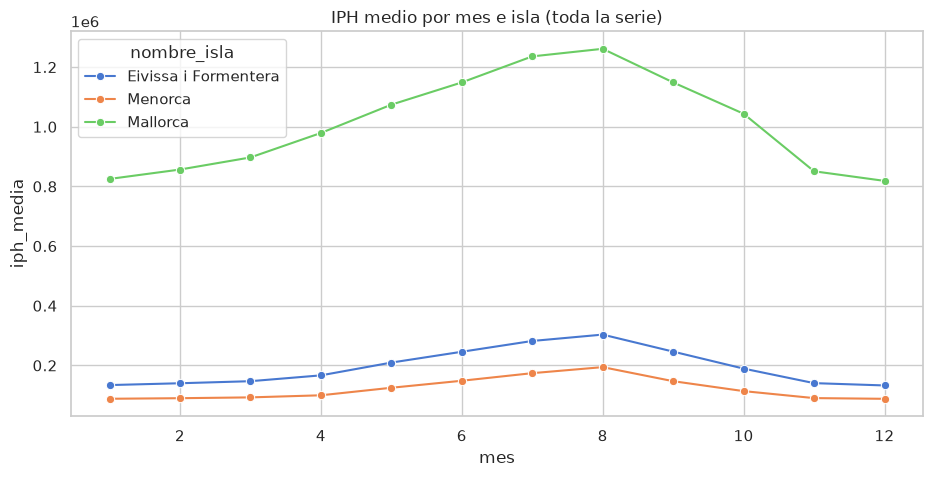

In [5]:
# Estacionalidad: IPH medio por mes e isla
mes_media = df.group_by(["nombre_isla", "mes"]).agg(pl.col("iph").mean().alias("iph_media"))
sns.lineplot(data=mes_media.to_pandas(), x="mes", y="iph_media", hue="nombre_isla", marker="o")
plt.title("IPH medio por mes e isla (toda la serie)")
plt.show()


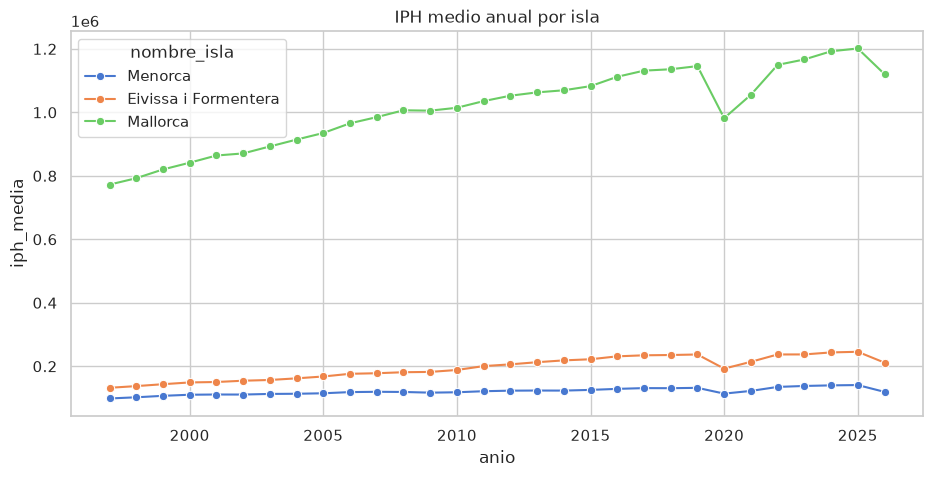

nombre_isla,anio,iph_media,iph_max
str,i64,f64,i64
"""Eivissa i Formentera""",2020,192595.083333,265697
"""Mallorca""",2018,1.1359e6,1414410
"""Eivissa i Formentera""",2015,222109.25,349289
"""Mallorca""",2016,1.1121e6,1415443
"""Menorca""",2020,113859.916667,170768
"""Mallorca""",2024,1.192467e6,1452598
"""Menorca""",2023,137979.416667,217581
"""Mallorca""",2023,1166705.5,1430194
"""Menorca""",2015,125566.083333,205912


In [6]:
# Features anuales por isla: media y maximo (estas entran al modelo)
anual = df.group_by(["nombre_isla", "anio"]).agg(
    iph_media=pl.col("iph").mean(),
    iph_max=pl.col("iph").max(),
)
sns.lineplot(data=anual.to_pandas(), x="anio", y="iph_media", hue="nombre_isla", marker="o")
plt.title("IPH medio anual por isla")
plt.show()

anual.filter(pl.col("anio") >= 2015).head(9)


**Conclusiones EDA**

- Serie mensual **completa** (1997-2026) para 3 series NUTS: Mallorca, Menorca y **Eivissa i Formentera (juntas)** — sin desglose por isla.
- Fuerte estacionalidad de verano (turismo), especialmente en Eivissa+Formentera.
- Features para el modelo: `iph_media` y `iph_max` anuales por isla (join a municipio via provincia 071/072 -> Eivissa i Formentera, 073 -> Mallorca, 074 -> Menorca).
